# Бейзлайн: логистическая регрессия с полным пайплайном
Цель: быстро проверить общий сигнал по таргету `Рез_экзамена` в полном пайплайне обработки.


In [1]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "README.md").exists()
    and (path / "Data_making").is_dir()
    and (path / "Models").is_dir()
)
DATA_PATH = (
    PROJECT_ROOT
    / "Data_making"
    / "synthetic_education_dushanbe_WITH_ROUNDED.csv"
)
METRICS_DIR = PROJECT_ROOT / "Models" / "Compare models"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix


## Данные
Коротко: читаем таблицу и проверяем, что загрузка прошла корректно.


In [2]:
# Данные
df = pd.read_csv(DATA_PATH)
df.head()

,ID_ученика,Класс,Район,Средний_балл,Часы_самоподготовки_в_неделю,Посещаемость_%,Уверенность_в_себе,Уровень_стресса_перед_экзаменом,Пропущенные_дни,Тип_школы,Рез_экзамена,Индекс_качества_школы,Стабильность_преподавателей,Доступ_к_ресурсам,Образовательная_среда
0,1,11,Исмоили Сомони,3.883,15,81.091,4.0,6.0,8,Обычная школа,1,0.4000,0.2911,0.3107,0.1970
1,2,11,Сино,3.915,15,87.872,4.0,4.0,10,Обычная школа,0,0.4443,0.2559,0.4509,0.5341
2,3,11,Шохмансур,3.660,5,71.282,5.0,6.0,13,Обычная школа,0,0.2499,0.1305,0.1049,0.2666
3,4,11,Исмоили Сомони,4.401,15,84.693,5.0,5.0,10,Обычная школа,1,0.5137,0.5229,0.4238,0.4449
4,5,11,Сино,4.311,12,75.941,5.0,4.0,9,Лицей/гимназия,1,0.4473,0.4858,0.4935,0.4143


In [3]:
# Таргет и удаление потенциальной утечки
# Средний_балл исключаем из baseline, т.к. это сильный прокси академической успеваемости
# и может давать оптимистичную оценку качества на задаче предсказания итогового результата.
y = df['Рез_экзамена']
leakage_cols = ['Средний_балл']
X = df.drop(columns=['Рез_экзамена', 'ID_ученика'] + leakage_cols, errors='ignore')

print('Исключены потенциальные leakage-признаки:', leakage_cols)
print('Форма X после очистки:', X.shape)

# Проверка баланса классов
y.value_counts(normalize=True)


Исключены потенциальные leakage-признаки: ['Средний_балл']
Форма X после очистки: (1525, 12)


Рез_экзамена
1    0.622295
0    0.377705
Name: proportion, dtype: float64

## Таргет и признаки
Цель — `Рез_экзамена`. `ID_ученика` исключаем, чтобы не было утечки.


In [4]:
# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# Определяем признаки
categorical_features = X.select_dtypes(include=['object']).columns
numeric_features = X.select_dtypes(exclude=['object']).columns

## Препроцессинг + модель
Числовые признаки: медиана + стандартизация. Категориальные: мода + OHE.


In [16]:
# Пайплайн
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')) ,
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')) ,
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

model = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')

clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', model)
])

In [17]:
# Обучение
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Класс', 'Часы_самоподготовки_в_неделю', 'Посещаемость_%',
       'Уверенность_в_себе', 'Уровень_стресса_перед_экзаменом',
       'Пропущенные_дни', 'Индекс_качества_школы',
       'Стабильность_преподавателей', 'Доступ_к_ресурсам',
       'Образовательная_среда'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Район', 'Тип_школы'], dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=500,
                                    random_state=42))])

## Оценка
Смотрим базовые метрики и матрицу ошибок на отложенной выборке.

In [18]:
# Оценка
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))
print('\nClassification report:\n', classification_report(y_test, y_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy: 0.7344262295081967
ROC AUC: 0.828924485125858

Classification report:
               precision    recall  f1-score   support

           0       0.62      0.75      0.68       115
           1       0.83      0.73      0.77       190

    accuracy                           0.73       305
   macro avg       0.72      0.74      0.73       305
weighted avg       0.75      0.73      0.74       305

Confusion matrix:
 [[ 86  29]
 [ 52 138]]


## Кросс-валидация
Проверяем устойчивость метрики на фолдах.

In [19]:
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
print('CV ROC AUC: %.3f ± %.3f' % (scores.mean(), scores.std()))

CV ROC AUC: 0.780 ± 0.017


## Визуализация метрик (Plotly)
Покажем основные метрики, ROC-кривую и матрицу ошибок в понятном виде.


In [20]:
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve

In [21]:
# Основные метрики
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'ROC AUC': roc_auc_score(y_test, y_proba),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred)
}
metrics_df = pd.DataFrame({'metric': list(metrics.keys()), 'value': list(metrics.values())})
fig_m = px.bar(metrics_df, x='metric', y='value', text='value', title='Основные метрики модели')
fig_m.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig_m.update_layout(yaxis=dict(range=[0, 1]))
fig_m.show()

In [22]:
# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC'))
fig_roc.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random', line=dict(dash='dash')))
fig_roc.update_layout(title='ROC-кривая', xaxis_title='FPR', yaxis_title='TPR')
fig_roc.show()

In [23]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
fig_cm = px.imshow(cm, text_auto=True, aspect='auto',
                   labels=dict(x='Predicted', y='Actual', color='Count'),
                   title='Матрица ошибок')
fig_cm.show()

## SHAP (интерпретация модели)
Покажем важность признаков и вклад в предсказание.


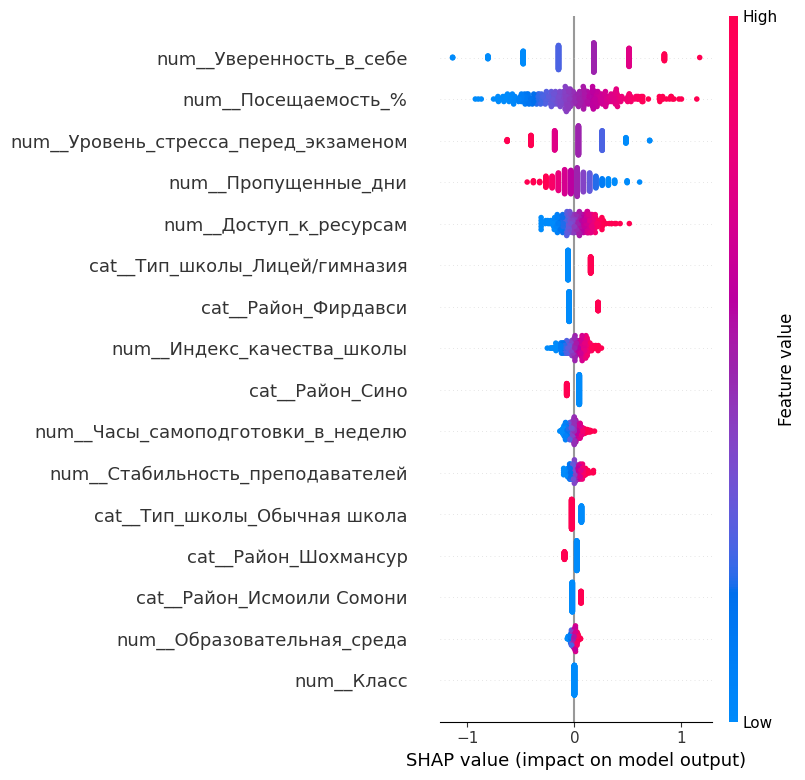

In [24]:
import shap

preprocess = clf.named_steps['preprocess']
model = clf.named_steps['model']

X_train_t = preprocess.transform(X_train)
X_test_t = preprocess.transform(X_test)

feature_names = preprocess.get_feature_names_out()

explainer = shap.LinearExplainer(model, X_train_t, feature_perturbation='interventional')
shap_values = explainer(X_test_t)

shap.summary_plot(shap_values, features=X_test_t, feature_names=feature_names, show=True)

## Сохранение метрик для сравнения


In [25]:
import json
# Метрики логистической регрессии (из уже вычисленных значений)
baseline_metrics = {
    'model': 'LogReg',
    'AUC': float(roc_auc_score(y_test, y_proba)),
    'Accuracy': float(accuracy_score(y_test, y_pred)),
    'Precision': float(precision_score(y_test, y_pred)),
    'Recall': float(recall_score(y_test, y_pred)),
    'F1': float(f1_score(y_test, y_pred)),
    'CV_AUC_mean': float(scores.mean()),
    'CV_AUC_std': float(scores.std()),
    'excluded_leakage_cols': leakage_cols
}

out_path = METRICS_DIR / "logreg_metrics.json"
out_path.write_text(json.dumps(baseline_metrics, ensure_ascii=False, indent=2), encoding="utf-8")
print('saved', out_path)
